## Chess online

1. Uploading and checking the data

In [2]:
import pandas as pd

chess_df=pd.read_csv('chess_games.csv', sep = ',')

chess_df.info()
chess_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   game_id            20058 non-null  int64 
 1   rated              20058 non-null  bool  
 2   turns              20058 non-null  int64 
 3   victory_status     20058 non-null  object
 4   winner             20058 non-null  object
 5   time_increment     20058 non-null  object
 6   white_id           20058 non-null  object
 7   white_rating       20058 non-null  int64 
 8   black_id           20058 non-null  object
 9   black_rating       20058 non-null  int64 
 10  moves              20058 non-null  object
 11  opening_code       20058 non-null  object
 12  opening_moves      20058 non-null  int64 
 13  opening_fullname   20058 non-null  object
 14  opening_shortname  20058 non-null  object
 15  opening_response   1207 non-null   object
 16  opening_variation  14398 non-null  objec

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN


2. Cleaning the data

In [3]:
for col in chess_df.select_dtypes(include=['object']).columns:
    chess_df[col] = chess_df[col].str.strip()

In [3]:
cols = [col for col in chess_df.select_dtypes(include=['object']).columns if col != 'opening_code']

print(cols)

for c in cols:
    chess_df[c] = chess_df[c].str.lower()

chess_df.head()

['victory_status', 'winner', 'time_increment', 'white_id', 'black_id', 'moves', 'opening_fullname', 'opening_shortname', 'opening_response', 'opening_variation']


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,out of time,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 nf3 bb4+ nc3 ba5...,D10,5,slav defense: exchange variation,slav defense,NaN,exchange variation
1,2,True,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 nxe5 qd4 nc6...,B00,4,nimzowitsch defense: kennedy variation,nimzowitsch defense,NaN,kennedy variation
2,3,True,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 be3 c6 be2 b5 nd2 a5 a4 c5 axb5 nc...,C20,3,king's pawn game: leonardis variation,king's pawn game,NaN,leonardis variation
3,4,True,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 nf3 bf5 nc3 nf6 bf4 ng4 e3 nc6 be2 qd7 o...,D02,3,queen's pawn game: zukertort variation,queen's pawn game,NaN,zukertort variation
4,5,True,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 nf3 d6 d4 nc6 d5 nb4 a3 na6 nc3 be7 b4 n...,C41,5,philidor defense,philidor defense,NaN,NaN


In [4]:
for c in chess_df[['rated', 'victory_status', 'winner', 'time_increment']]:
    print(c)
    print(chess_df[c].unique().tolist())
    print('-----------')

rated
[False, True]
-----------
victory_status
['out of time', 'resign', 'mate', 'draw']
-----------
winner
['white', 'black', 'draw']
-----------
time_increment
['15+2', '5+10', '20+0', '30+3', '10+0', '15+30', '15+0', '20+60', '5+40', '8+0', '15+15', '15+16', '11+0', '30+60', '15+5', '10+10', '15+3', '18+0', '30+30', '20+25', '5+5', '30+0', '40+40', '16+0', '6+10', '8+10', '8+12', '7+12', '15+10', '20+5', '20+10', '45+0', '5+8', '30+2', '25+0', '10+2', '7+2', '25+25', '7+8', '6+6', '10+4', '12+0', '15+1', '2+10', '9+0', '10+9', '6+7', '30+10', '30+15', '10+3', '45+30', '9+2', '7+3', '6+5', '25+5', '5+7', '8+2', '20+8', '30+5', '25+15', '15+7', '8+8', '5+9', '16+7', '10+7', '7+5', '40+20', '10+5', '11+5', '10+15', '180+0', '17+5', '8+5', '3+8', '60+120', '90+120', '15+8', '9+1', '9+3', '2+15', '10+1', '5+12', '60+10', '5+60', '8+15', '30+25', '12+1', '14+0', '60+20', '10+8', '20+3', '14+12', '7+7', '60+0', '45+45', '4+15', '5+6', '180+180', '8+3', '4+6', '10+25', '3+10', '7+4', '6+3',

In [6]:
import numpy as np

chess_df.info()

for col in chess_df.select_dtypes(include=['object', 'bool', 'int64']).columns:
    chess_df[col] = chess_df[col].replace(['', 'unknown'], np.nan)

chess_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   game_id            20058 non-null  int64 
 1   rated              20058 non-null  bool  
 2   turns              20058 non-null  int64 
 3   victory_status     20058 non-null  object
 4   winner             20058 non-null  object
 5   time_increment     20058 non-null  object
 6   white_id           20058 non-null  object
 7   white_rating       20058 non-null  int64 
 8   black_id           20058 non-null  object
 9   black_rating       20058 non-null  int64 
 10  moves              20058 non-null  object
 11  opening_code       20058 non-null  object
 12  opening_moves      20058 non-null  int64 
 13  opening_fullname   20058 non-null  object
 14  opening_shortname  20058 non-null  object
 15  opening_response   1207 non-null   object
 16  opening_variation  14398 non-null  objec

In [7]:
print(chess_df.duplicated().sum())

0


In [8]:
chess_df.tail(3)

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
20055,20056,True,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 bf4 nc6 e3 nf6 c3 e6 nf3 be7 bd3 o-o nbd...,D00,3,queen's pawn game: mason attack,queen's pawn game,NaN,mason attack
20056,20057,True,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 nf6 e5 dxe5 dxe5 qxd1+ kxd1 nd5 c4 nb...,B07,4,pirc defense,pirc defense,NaN,NaN
20057,20058,True,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 bf4 na6 e3 e6 c3 nf6 nf3 bd7 nbd2 b5 bd3...,D00,3,queen's pawn game: mason attack,queen's pawn game,NaN,mason attack


3. Data analysis

 White pieces won 49.86% of the games, while black won 45.4%.
 Draws accounted for 4.74% of the games.


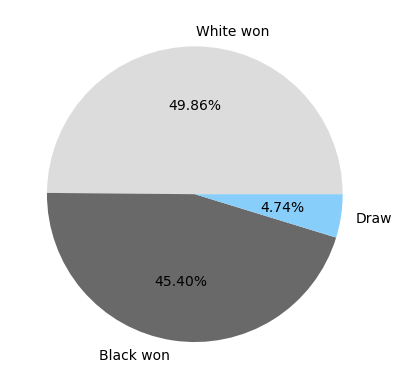

In [34]:
## What percentage of games are won by white pieces and what percentage by black? How many end in a draw?
white_df=chess_df[chess_df['winner']=='white']
black_df=chess_df[chess_df['winner']=='black']
draw_df=chess_df[chess_df['winner']=='draw']
white_won=round(white_df['winner'].count()/chess_df['winner'].count()*100, 2)
black_won=round(black_df['winner'].count()/chess_df['winner'].count()*100, 2)
draw_won=round(draw_df['winner'].count()/chess_df['winner'].count()*100, 2)
print(f' White pieces won {white_won}% of the games, while black won {black_won}%.')
print(f' Draws accounted for {draw_won}% of the games.')

#pie chart
import matplotlib.pyplot as plt
values=[white_won,black_won,draw_won]
plt.pie(values, labels=['White won', 'Black won', 'Draw'], colors=['gainsboro','dimgray', 'lightskyblue'], autopct='%.2f%%')
plt.show()

Top 10 players with the most wins:
taranga               72
vladimir-kramnik-1    50
a_p_t_e_m_u_u         46
chesscarl             45
ducksandcats          43
king5891              42
doraemon61            38
smilsydov             36
anakgreget            36
laode_syahril         34
Name: count, dtype: int64


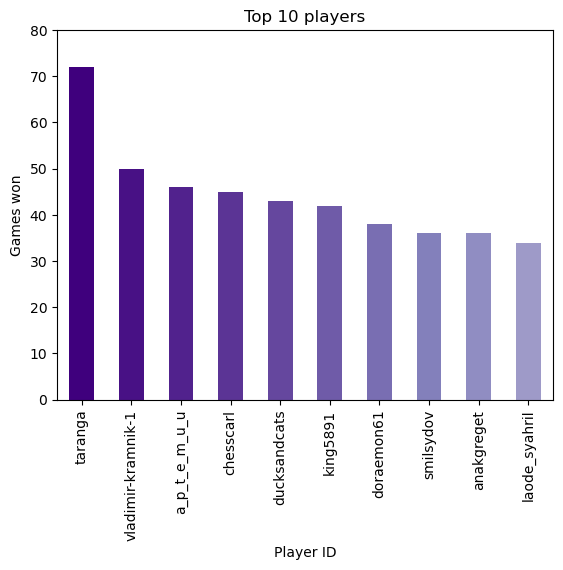

In [59]:
##Who are the top 10 players across all games?
white_wins=chess_df[chess_df['winner']=='white']['white_id']
black_wins=chess_df[chess_df['winner']=='black']['black_id']
all_winners=pd.concat([white_wins, black_wins])
top_players=all_winners.value_counts().head(10)
print(f'Top 10 players with the most wins:')
print(top_players)

#bar chart
import numpy as np
colors = plt.cm.Purples(np.linspace(1, 0.5, len(top_players)))
top_players.plot(kind='bar', color=colors)
plt.title('Top 10 players')
plt.ylabel('Games won')
plt.yticks(np.arange(0,90,10))
plt.xlabel('Player ID')
plt.show()

In [58]:
## Which opening was used most often in games won by black pieces? And in games won by white?
grouped_w=white_df.groupby('opening_shortname').size().sort_values(ascending=False).head(3)
grouped_b=black_df.groupby('opening_shortname').size().sort_values(ascending=False).head(3)

print(f'Top 3 openings in games won by black pieces:')
print(grouped_b.to_string(header=False))
print('--------------------')
print(f'Top 3 openings in games won by white pieces:') 
print(grouped_w.to_string(header=False))
print('--------------------')
print('Conclusion: The Sicilian Defense was the most common opening in games won by both white and black pieces.')

Top 3 openings in games won by black pieces:
sicilian defense     1299
french defense        653
queen's pawn game     602
--------------------
Top 3 openings in games won by white pieces:
sicilian defense     1203
french defense        689
queen's pawn game     570
--------------------
Conclusion: The Sicilian Defense was the most common opening in games won by both white and black pieces.


In [17]:
## What percentage of games are won by the higher-rated player? Does it depend on the color of the pieces?
higher_r_wins=0
higher_r_wins_w=0
higher_r_wins_b=0
total_higher_r_games=0

for _, row in chess_df.iterrows():
    if row['white_rating']>row['black_rating']:
        higher='white'
    elif row ['black_rating']>row['white_rating']:
        higher='black'
    else:
        continue

    total_higher_r_games+=1

    if row['winner']==higher:
        higher_r_wins+=1
        if higher=='white':
            higher_r_wins_w+=1
        else:
            higher_r_wins_b+=1

if total_higher_r_games>0:
    all_percent=round((higher_r_wins/total_higher_r_games)*100, 2)
    w_percent=round((higher_r_wins_w/total_higher_r_games)*100, 2)
    b_percent=round((higher_r_wins_b/total_higher_r_games)*100, 2)

    print(f'Players with a higher rating win {all_percent}% of the games.')
    print(f'Higher-rated players playing with white pieces win {w_percent}% of the games.')
    print(f'Higher-rated players playing with black pieces win {b_percent}% of the games.')

print('------------')
print('Conclusion: Rating significantly affects the number of games won - 62.21%. Color also matters, but not significantly. Higher-rated players playing with white pieces win 3.55% more games than higher-rated players that play with black pieces.')

Players with a higher rating win 62.21% of the games.
Higher-rated players playing with white pieces win 32.88% of the games.
Higher-rated players playing with black pieces win 29.33% of the games.
------------
Conclusion: Rating significantly affects the number of games won - 62.21%. Color also matters, but not significantly. Higher-rated players playing with white pieces win 3.55% more games than higher-rated players that play with black pieces.
